# Fuel Blending LP: Simplex Method and Visualization

---

This notebook develops a small **linear programming (LP)** problem for fuel blending.  
The model is intentionally limited to **two decision variables** so that:

1. the feasible region can be visualized as a polygon (polytope in 2-D),
2. the optimal solution can be understood geometrically,
3. the same problem can be solved using Pyomo, and
4. the example can be used to demonstrate the simplex method.

## Problem Description

---

A plant can use two fuels: **Fuel A** and **Fuel B** in which

$$ x_1 = \text{tons of Fuel A used} $$
$$ x_2 = \text{tons of Fuel B used} $$

Fuel A provides a benefit of PhP 30.00 per ton, while Fuel B provides a benefit of PhP 40.00 per ton.

The plant wants to maximize total benefit, but it is subject to two limits:

- a **sulfur limit**, and
- a **fuel budget limit**.

The data are summarized below.

| Property | Fuel A | Fuel B |
|---|---:|---:|
| Benefit per ton | 30 | 40 |
| Cost per ton | 20 | 30 |
| Sulfur index per ton | 3 | 1 |

The maximum allowed sulfur index is 180, while the maximum fuel budget is PhP 2400.00.

## Mathematical Formulation

---

### Decision variables

* $ x_1 \geq 0 $ tons of Fuel A used, and
* $ x_2 \geq 0 $ tons of Fuel B used.

### Objective function

The objective is to maximize the benefit:

$$ \max \; Z = 30x_1 + 40x_2 $$

### Sulfur constraint

Fuel A contributes 3 sulfur-index units per ton, while Fuel B contributes 1 sulfur-index unit per ton.

$$ 3x_1 + x_2 \leq 180 $$

### Budget constraint

Fuel A costs PhP 20.00 per ton and Fuel B costs PhP 30.00 per ton. Hence:

$$ 20x_1 + 30x_2 \leq 2400 $$

Dividing by 10 gives the equivalent constraint:

$$ 2x_1 + 3x_2 \leq 240 $$

### Nonnegativity constraints
Amount of fuel cannot be negative:

$$ x_1,x_2 \geq 0 $$

Thus, the complete LP is

$$
\boxed{
\begin{aligned}
\max_{x_1,x_2}\quad
&30x_1+40x_2\\
\text{s.t.}\quad
&3x_1+x_2\leq180\\
&2x_1+3x_2\leq240\\
&x_1,x_2\geq0.
\end{aligned}
}
$$

## Standard form for the simplex method

---

Slack variables $s_1$ and $s_2$ convert the inequalities into equalities:

$$ 3x_1+x_2+s_1=180 $$
$$ 2x_1+3x_2+s_2=240 $$

with

$$ x_1,x_2,s_1,s_2\geq0. $$

The initial basic feasible solution is obtained by setting the decision variables to zero:

$$ x_1=x_2=0. $$

Therefore,

$$ s_1=180,\qquad s_2=240. $$

The initial point of the simplex method is consequently the origin,

$$ (x_1,x_2)=(0,0). $$

Each simplex pivot can be interpreted geometrically as moving from one vertex of the feasible polygon to another adjacent vertex.

## Pyomo implementation

In [1]:
import pyomo.environ as pyo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create the optimization model
model = pyo.ConcreteModel()

# Decision variables
model.x1 = pyo.Var(domain=pyo.NonNegativeReals)
model.x2 = pyo.Var(domain=pyo.NonNegativeReals)

# Objective: maximize total benefit
model.obj = pyo.Objective(
    expr=30*model.x1 + 40*model.x2,
    sense=pyo.maximize
)

# Sulfur limit
model.sulfur_constraint = pyo.Constraint(
    expr=3*model.x1 + model.x2 <= 180
)

# Budget limit
model.budget_constraint = pyo.Constraint(
    expr=2*model.x1 + 3*model.x2 <= 240
)

model.pprint()

2 Var Declarations
    x1 : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals
    x2 : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 30*x1 + 40*x2

2 Constraint Declarations
    budget_constraint : Size=1, Index=None, Active=True
        Key  : Lower : Body        : Upper : Active
        None :  -Inf : 2*x1 + 3*x2 : 240.0 :   True
    sulfur_constraint : Size=1, Index=None, Active=True
        Key  : Lower : Body      : Upper : Active
        None :  -Inf : 3*x1 + x2 : 180.0 :   True

5 Declarations: x1 x2 obj sulfur_constraint budget_constraint


## Solve the LP
We'll use the GLPK solver, good for small to moderate LP and MILP problems.

In [3]:
solver = pyo.SolverFactory("glpk")
results = solver.solve(model, tee=False)

print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)

Solver status: ok
Termination condition: optimal


## Optimal solution

In [4]:
x1_opt = pyo.value(model.x1)
x2_opt = pyo.value(model.x2)
z_opt = pyo.value(model.obj)

solution = pd.DataFrame({
    "Quantity": [
        "Fuel A used",
        "Fuel B used",
        "Maximum benefit"
    ],
    "Symbol": [
        "x1",
        "x2",
        "Z"
    ],
    "Value": [
        x1_opt,
        x2_opt,
        z_opt
    ]
})

solution

,Quantity,Symbol,Value
0,Fuel A used,x1,42.857143
1,Fuel B used,x2,51.428571
2,Maximum benefit,Z,3342.857143


In [5]:
# Evaluate the left-hand side of each constraint
sulfur_used = 3*x1_opt + x2_opt
budget_index_used = 2*x1_opt + 3*x2_opt

constraint_results = pd.DataFrame({
    "Constraint": ["Sulfur", "Budget"],
    "LHS at optimum": [sulfur_used, budget_index_used],
    "RHS": [180, 240],
    "Slack": [180 - sulfur_used, 240 - budget_index_used]
})

constraint_results

,Constraint,LHS at optimum,RHS,Slack
0,Sulfur,180.0,180,-1.136868e-13
1,Budget,240.0,240,0.000000e+00


## Vertices of the feasible polytope

In [6]:
# Vertices can be obtained analytically for this small two-variable problem.
vertices = np.array([
    [0.0, 0.0],
    [60.0, 0.0],          # sulfur constraint intercept
    [300/7, 360/7],       # intersection of sulfur and budget constraints
    [0.0, 80.0]           # budget constraint intercept
])

vertex_df = pd.DataFrame(vertices, columns=["x1", "x2"])
vertex_df["Objective"] = 30*vertex_df["x1"] + 40*vertex_df["x2"]

vertex_df

,x1,x2,Objective
0,0.000000,0.000000,0.000000
1,60.000000,0.000000,1800.000000
2,42.857143,51.428571,3342.857143
3,0.000000,80.000000,3200.000000


## Visualization of the feasible region

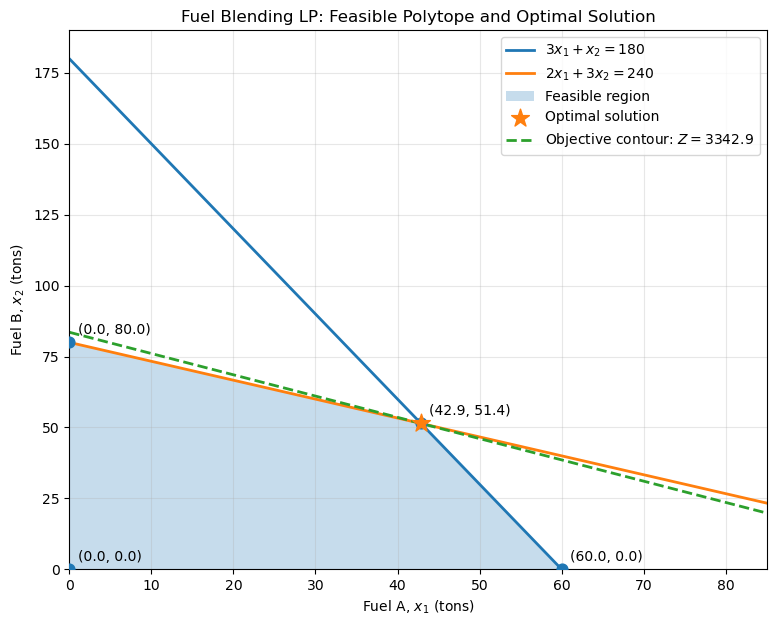

In [7]:
# Coordinate range
x1 = np.linspace(0, 85, 500)

# Boundary lines
x2_sulfur = 180 - 3*x1
x2_budget = (240 - 2*x1)/3

fig, ax = plt.subplots(figsize=(9, 7))

# Plot constraint boundaries
ax.plot(x1, x2_sulfur, linewidth=2, label=r"$3x_1+x_2=180$")
ax.plot(x1, x2_budget, linewidth=2, label=r"$2x_1+3x_2=240$")

# Shade feasible polygon
poly = plt.Polygon(vertices, alpha=0.25, label="Feasible region")
ax.add_patch(poly)

# Plot vertices
ax.scatter(vertices[:, 0], vertices[:, 1], s=60, zorder=5)

for i, (vx, vy) in enumerate(vertices):
    ax.annotate(
        f"({vx:.1f}, {vy:.1f})",
        (vx, vy),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Plot optimum
ax.scatter([x1_opt], [x2_opt], s=180,
    marker="*", zorder=6, label="Optimal solution")

# Plot one objective-function contour through the optimum
# 30*x1 + 40*x2 = Z*
x2_obj = (z_opt - 30*x1)/40
ax.plot(x1, x2_obj, linestyle="--", linewidth=2, 
        label=rf"Objective contour: $Z={z_opt:.1f}$")

ax.set_xlim(0, 85)
ax.set_ylim(0, 190)
ax.set_xlabel(r"Fuel A, $x_1$ (tons)")
ax.set_ylabel(r"Fuel B, $x_2$ (tons)")
ax.set_title("Fuel Blending LP: Feasible Polytope and Optimal Solution")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

## Interpretation

The feasible region is the polygon satisfying all model constraints simultaneously.

Because the objective function is linear, its contours are straight lines:

$$ 30x_1+40x_2=Z. $$

Increasing $Z$ shifts this line outward while preserving its slope.  

The highest objective contour that still touches the feasible region reaches the polygon at

$$ \boxed{ (x_1^*,x_2^*)\approx(42.857,51.429) } $$

where both the sulfur and budget constraints are active.

Hence, the solution uses approximately

$$ \boxed{42.86\text{ tons of Fuel A}} $$

and

$$ \boxed{51.43\text{ tons of Fuel B}}. $$

The maximum benefit is approximately

$$ \boxed{Z^*=3342.86}. $$

This geometric interpretation is closely related to the simplex method. The simplex algorithm does not search every point inside the polygon. Instead, it moves between **basic feasible solutions**, which correspond to the **vertices of the feasible polytope**, until no neighboring vertex improves the objective.

## Optional: verify all vertices manually

For a two-variable LP, we can directly evaluate the objective at every feasible vertex.  
This is not how large LPs are normally solved, but it illustrates why an LP optimum occurs at a vertex.

In [8]:
vertex_check = vertex_df.copy()

best_index = vertex_check["Objective"].idxmax()
vertex_check["Optimal?"] = False
vertex_check.loc[best_index, "Optimal?"] = True

vertex_check

,x1,x2,Objective,Optimal?
0,0.000000,0.000000,0.000000,False
1,60.000000,0.000000,1800.000000,False
2,42.857143,51.428571,3342.857143,True
3,0.000000,80.000000,3200.000000,False
